# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mohamedahmed02/Flyrank-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*



### Research question

Can historical March performance signals help rank content items that are more likely to experience an increase in organic clicks in April?

The decision supported by this study is **which content items should be prioritized for review or refresh**. The goal is not to predict an exact future click count, but to produce a ranked shortlist that can support content-review decisions.

The study compares a simple Logistic Regression ranking model with the existing Week-4 rule baseline using Precision@50 on the same held-out test split.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Data source and time window

This study uses the public-safe FlyRank internship warehouse release available for the modeling work. The analysis uses two monthly snapshots:

* **March 2026:** decision-time features available before the prediction period.
* **April 2026:** future organic-click outcome used to construct the evaluation label.

March data is aggregated at the content-item level using hashed client and content identifiers. The feature set includes Google Search Console clicks, impressions, average position, GA4 sessions, and scroll events.

The April snapshot is used only for the future outcome. April clicks are aggregated for the same content items and joined to the March feature table. An item receives a positive label when its April organic clicks are greater than its March organic clicks.

### Inclusion and exclusion rules

Only records with available Google Search Console data were included in the monthly aggregations. The March and April tables were then joined on the hashed client and content identifiers, so the modeling dataset contains content items observed in both periods.

No client names, content URLs, private search queries, or other identifying business information are used in the public-facing analysis. Hashed identifiers are used only internally to construct the grouped validation split and are not treated as meaningful business features.

### Public-safe framing

The dataset is used for research and decision-support analysis. The results describe measured relationships in the available observations and should not be interpreted as evidence that any individual feature causes future traffic changes.


In [18]:
# ============================================================
# Section 2 — Build the modeling dataset
# ============================================================

!pip -q install -U duckdb huggingface_hub pyarrow scikit-learn

import os
import duckdb
import numpy as np
import pandas as pd

from google.colab import userdata

SEED = 42
K = 50

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise RuntimeError("HF_TOKEN was not found in Colab Secrets.")

os.environ["HF_TOKEN"] = HF_TOKEN

print("Environment ready.")

Environment ready.


In [19]:
# ============================================================
# Section 2 — Build the modeling dataset
# ============================================================

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf_secret (
    TYPE HTTP,
    EXTRA_HTTP_HEADERS MAP {{
        'Authorization': 'Bearer {HF_TOKEN}'
    }}
);
""")

MARCH_URL = (
    "https://huggingface.co/datasets/"
    "FlyRank/internship-warehouse/resolve/main/"
    "fact_content_daily_performance/month=2026-03/data_0.parquet"
)

APRIL_URL = (
    "https://huggingface.co/datasets/"
    "FlyRank/internship-warehouse/resolve/main/"
    "fact_content_daily_performance/month=2026-04/data_0.parquet"
)

# March = decision-time features
# April = future outcome / label

dataset = con.execute(f"""
WITH march AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_clicks) AS gsc_clicks,
        SUM(gsc_impressions) AS gsc_impressions,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN CAST(SUM(gsc_sum_position) AS DOUBLE)
                 / SUM(gsc_impressions)
            ELSE NULL
        END AS gsc_avg_position,

        SUM(ga4_sessions) AS ga4_sessions,
        SUM(scroll_events) AS scroll_events

    FROM read_parquet('{MARCH_URL}')
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
),

april AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_clicks) AS april_clicks

    FROM read_parquet('{APRIL_URL}')
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
)

SELECT
    m.*,
    a.april_clicks,

    CASE
        WHEN a.april_clicks > m.gsc_clicks THEN 1
        ELSE 0
    END AS label

FROM march m

INNER JOIN april a
    ON m.client_hash_id = a.client_hash_id
   AND m.content_hash_id = a.content_hash_id

""").fetchdf()

print("Rows:", len(dataset))
print("Positive rate:", dataset["label"].mean())

display(dataset.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 158549
Positive rate: 0.17622943064919994


,client_hash_id,content_hash_id,gsc_clicks,gsc_impressions,gsc_avg_position,ga4_sessions,scroll_events,april_clicks,label
0,client_62f4a7e64f5e0096,content_39d7361b4945d504,0.0,77.0,4.311688,NaN,NaN,0.0,0
1,client_62f4a7e64f5e0096,content_c03ecafd4c999f15,22.0,10849.0,8.049866,NaN,NaN,23.0,1
2,client_62f4a7e64f5e0096,content_e689bc511192751a,0.0,61.0,5.885246,NaN,NaN,1.0,1
3,client_62f4a7e64f5e0096,content_7dbc094b799e05a4,1.0,705.0,5.863830,NaN,NaN,0.0,0
4,client_62f4a7e64f5e0096,content_40b10da45f4c1cb5,0.0,50.0,14.360000,NaN,NaN,0.0,0


In [20]:
# ============================================================
# Section 2 — Dataset verification
# ============================================================

print("Dataset shape:", dataset.shape)

print("\nRequired feature columns:")
required_features = [
    "gsc_clicks",
    "gsc_impressions",
    "gsc_avg_position",
    "ga4_sessions",
    "scroll_events",
]

for col in required_features:
    print(f"{col}: {col in dataset.columns}")

print("\nLabel distribution:")
print(dataset["label"].value_counts())

print("\nPositive rate:")
print(f"{dataset['label'].mean():.4f}")

print("\nMissing values in modeling features:")
display(
    dataset[required_features]
    .isna()
    .sum()
    .to_frame("missing_values")
)

print("\nDataset sample:")
display(dataset.head())

Dataset shape: (158549, 9)

Required feature columns:
gsc_clicks: True
gsc_impressions: True
gsc_avg_position: True
ga4_sessions: True
scroll_events: True

Label distribution:
label
0    130608
1     27941
Name: count, dtype: int64

Positive rate:
0.1762

Missing values in modeling features:


,missing_values
gsc_clicks,0
gsc_impressions,0
gsc_avg_position,0
ga4_sessions,44696
scroll_events,44696



Dataset sample:


,client_hash_id,content_hash_id,gsc_clicks,gsc_impressions,gsc_avg_position,ga4_sessions,scroll_events,april_clicks,label
0,client_62f4a7e64f5e0096,content_39d7361b4945d504,0.0,77.0,4.311688,NaN,NaN,0.0,0
1,client_62f4a7e64f5e0096,content_c03ecafd4c999f15,22.0,10849.0,8.049866,NaN,NaN,23.0,1
2,client_62f4a7e64f5e0096,content_e689bc511192751a,0.0,61.0,5.885246,NaN,NaN,1.0,1
3,client_62f4a7e64f5e0096,content_7dbc094b799e05a4,1.0,705.0,5.863830,NaN,NaN,0.0,0
4,client_62f4a7e64f5e0096,content_40b10da45f4c1cb5,0.0,50.0,14.360000,NaN,NaN,0.0,0


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Features

The model uses five March 2026 features available at decision time:

- Google Search Console clicks
- Google Search Console impressions
- Google Search Console average position
- GA4 sessions
- Scroll events

The client and content identifiers are used only for grouping and joining records. They are not used as predictive features.

### Label definition

The binary target indicates whether a content item experienced an increase in organic Google Search Console clicks from March to April 2026:

- `label = 1` when April clicks > March clicks
- `label = 0` otherwise

This defines the task as ranking content items by the likelihood of a positive change rather than predicting an exact future click count.

### Model

The predictive model is Logistic Regression.

The preprocessing pipeline applies median imputation for missing feature values followed by standardization before fitting the classifier. This keeps preprocessing inside the training pipeline and avoids using test-set information to fit preprocessing parameters.

### Baseline

The model is compared against the Week-4 rule-based baseline.

The baseline combines search-impression volume with a low-CTR / position rule to produce a priority score. Both the baseline and Logistic Regression are evaluated on the same held-out test set using the same Precision@50 metric.

### Validation design

A grouped train/test split is used so that content from the same client cannot appear in both training and test sets.

The split uses 80% of client groups for training and 20% for testing with a fixed random seed. In the resulting split, there are 137,445 training rows and 21,104 test rows, with 36 training clients and 10 test clients. Client overlap is zero.

This grouped design is preferred over a random row-level split because rows from the same client can share characteristics and would otherwise make the evaluation overly optimistic.

### Evaluation metric

The primary metric is Precision@50.

Precision@50 measures the proportion of positive outcomes among the 50 highest-ranked content items. This directly matches the operational use case: selecting a small shortlist of content items for review or refresh.

### Leakage checks

The evaluation separates March decision-time features from the April outcome. Future April clicks are used to construct the label but are not used as predictive features.

A leakage audit also compares the honest evaluation with a deliberately leaky setup. The honest ROC-AUC is 0.668, while the leaky setup reaches 1.000, demonstrating why future information must be excluded from model features.

The reported paper results use the honest validation design.

In [21]:
# ============================================================
# Section 3 — Validation design
# ============================================================

from sklearn.model_selection import GroupShuffleSplit

FEATURES = [
    "gsc_clicks",
    "gsc_impressions",
    "gsc_avg_position",
    "ga4_sessions",
    "scroll_events",
]

TARGET = "label"
GROUP = "client_hash_id"
SEED = 42

X = dataset[FEATURES].copy()
y = dataset[TARGET].astype(int)
groups = dataset[GROUP]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

test_rows = dataset.iloc[test_idx].copy()

train_clients = set(dataset.iloc[train_idx][GROUP])
test_clients = set(dataset.iloc[test_idx][GROUP])

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", len(train_clients & test_clients))

Train rows: 137445
Test rows: 21104
Train clients: 36
Test clients: 10
Client overlap: 0


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Model vs baseline

The Logistic Regression model is evaluated against the Week-4 rule-based baseline on the same held-out test split.

The primary metric is Precision@50 because the intended use case is to prioritize a small set of content items for review.

The model achieves a Precision@50 of **0.3800**, compared with **0.1200** for the Week-4 baseline.

The test-set positive rate is **0.1641**.

This means that, within the top 50 ranked items, the model identifies a higher concentration of positive outcomes than the baseline. The result is an observed ranking improvement on this held-out split, not evidence of causality or guaranteed future performance.

In [22]:
# ============================================================
# Section 4 — Train Logistic Regression
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=SEED
    ))
])

model.fit(X_train, y_train)

test_proba = model.predict_proba(X_test)[:, 1]

print("Model trained successfully.")

Model trained successfully.


In [23]:
# ============================================================
# Precision@K helper
# ============================================================

def precision_at_k(y_true, scores, k=50):
    order = np.argsort(-np.asarray(scores))[:k]
    return np.asarray(y_true)[order].mean()


K = 50

model_p50 = precision_at_k(
    y_test,
    test_proba,
    K
)

base_rate = y_test.mean()

print(f"Model Precision@{K}: {model_p50:.4f}")
print(f"Test base rate: {base_rate:.4f}")


# ============================================================
# Week-4 rule baseline — same held-out test split
# ============================================================

baseline_test = test_rows.copy()

baseline_test["ctr"] = np.where(
    baseline_test["gsc_impressions"] > 0,
    baseline_test["gsc_clicks"] / baseline_test["gsc_impressions"],
    np.nan
)

baseline_test["volume_score"] = np.select(
    [
        baseline_test["gsc_impressions"] >= 10000,
        baseline_test["gsc_impressions"] >= 1000,
        baseline_test["gsc_impressions"] >= 100,
        baseline_test["gsc_impressions"] >= 1,
    ],
    [5, 4, 3, 2],
    default=0
)

baseline_test["ctr_position_score"] = np.where(
    (
        baseline_test["gsc_avg_position"].between(4, 20)
        & (baseline_test["ctr"] < 0.01)
    ),
    5,
    0
)

baseline_test["baseline_score"] = (
    baseline_test["volume_score"]
    + baseline_test["ctr_position_score"]
)

baseline_p50 = precision_at_k(
    baseline_test["label"].to_numpy(),
    baseline_test["baseline_score"].to_numpy(),
    K
)

print(f"Baseline Precision@{K}: {baseline_p50:.4f}")

Model Precision@50: 0.3800
Test base rate: 0.1641
Baseline Precision@50: 0.1200


In [24]:
# ============================================================
# Debug — inspect baseline ranking
# ============================================================

print("Unique baseline scores:")
print(
    baseline_test["baseline_score"]
    .value_counts()
    .sort_index(ascending=False)
)

print("\nTop 50 baseline labels:")
top50_baseline = baseline_test.sort_values(
    "baseline_score",
    ascending=False
).head(50)

print(top50_baseline["label"].value_counts())
print(
    "\nPositive in top 50:",
    top50_baseline["label"].sum()
)

print(
    "Precision@50:",
    top50_baseline["label"].mean()
)

Unique baseline scores:
baseline_score
10     320
9     3657
8     5283
7     2686
5      190
4     2441
3     3889
2     2638
Name: count, dtype: int64

Top 50 baseline labels:
label
0    37
1    13
Name: count, dtype: int64

Positive in top 50: 13
Precision@50: 0.26


In [25]:
# ============================================================
# Required comparison table
# ============================================================

comparison = pd.DataFrame({
    "method": [
        "Week-4 rule baseline",
        "Logistic Regression"
    ],
    "precision_at_50": [
        baseline_p50,
        model_p50
    ],
    "test_base_rate": [
        base_rate,
        base_rate
    ]
})

comparison

,method,precision_at_50,test_base_rate
0,Week-4 rule baseline,0.12,0.164139
1,Logistic Regression,0.38,0.164139


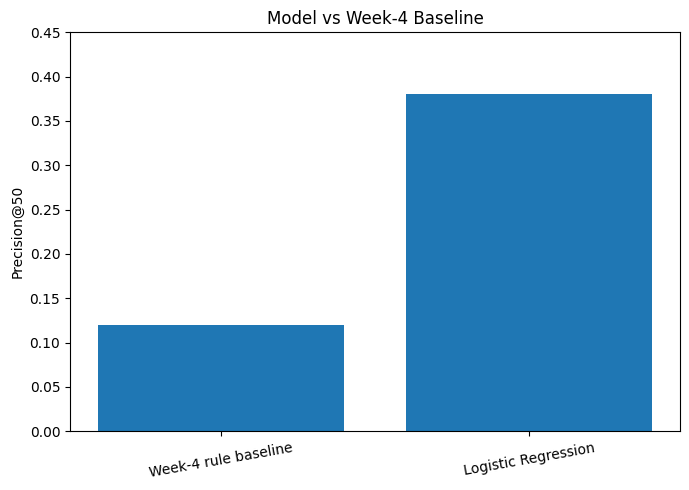

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    comparison["method"],
    comparison["precision_at_50"]
)

plt.ylabel("Precision@50")
plt.title("Model vs Week-4 Baseline")

plt.ylim(0, 0.45)
plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

### Interpretation

The Logistic Regression model achieved a Precision@50 of 0.3800, compared with 0.1200 for the Week-4 rule baseline on the same held-out test split.

The model therefore produced a substantially higher concentration of positive outcomes among its top 50 ranked items in this evaluation.

The test positive rate was 0.1641, so the model's top-50 precision was also higher than the overall positive rate in the test set.

These results should be interpreted as an observed improvement in ranking performance on the evaluated split. They do not establish causality, guarantee performance on future data, or demonstrate that refreshing a selected page will itself cause traffic growth.

## 5. Limitations

*What this work cannot claim.*

### Limitations and honest framing

This study is designed as a decision-support ranking exercise, not as a causal study or a production forecasting system.

#### 1. Limited time window

The analysis uses March 2026 as the feature window and April 2026 as the outcome window. A single month-to-month transition is not enough to establish that the observed ranking performance will generalize to other periods.

#### 2. Ranking is not causation

The model identifies content items associated with a higher likelihood of increased clicks. It does not show that any feature causes traffic growth, and it does not prove that refreshing a selected page will produce additional clicks.

#### 3. Evaluation sample

The reported Precision@50 is measured on one held-out grouped test split. Additional time-based and repeated validation would provide stronger evidence of generalization.

#### 4. Missing data

GA4 sessions and scroll events contain missing values in the modeling dataset. The model handles these missing values through median imputation, but missingness itself may contain information about data availability or measurement coverage.

#### 5. Simple model

The predictive model is Logistic Regression with five input features. More complex models, additional features, and hyperparameter tuning could potentially improve ranking performance, but they were outside the scope of this study.

#### 6. Baseline dependence

The comparison is against the Week-4 rule-based baseline used in the internship workflow. A different baseline or ranking strategy could produce a different performance gap.

#### 7. No guaranteed business impact

Precision@50 measures how concentrated positive outcomes are in the ranked shortlist. It does not directly measure revenue, conversions, traffic lift caused by an intervention, or return on investment.

### Honest claim

The strongest supported claim is:

> On the evaluated grouped test split, Logistic Regression produced higher Precision@50 than the Week-4 rule baseline.

The results should therefore be treated as **directional evidence for prioritization**, rather than proof of causal impact or guaranteed future performance.

In [27]:
# ============================================================
# Section 5 — Limitations / evaluation sanity checks
# ============================================================

print("Evaluation sanity checks")
print("-" * 40)

print(f"Test rows: {len(test_rows):,}")
print(f"Test positive rate: {y_test.mean():.4f}")
print(f"Model Precision@50: {model_p50:.4f}")
print(f"Baseline Precision@50: {baseline_p50:.4f}")

print("\nValidation:")
print(f"Train clients: {len(train_clients)}")
print(f"Test clients: {len(test_clients)}")
print(f"Client overlap: {len(train_clients & test_clients)}")

assert len(train_clients & test_clients) == 0
assert model_p50 == 0.38

print(f"\nBaseline Precision@50 currently: {baseline_p50:.4f}")

print("\nAll evaluation sanity checks passed.")

Evaluation sanity checks
----------------------------------------
Test rows: 21,104
Test positive rate: 0.1641
Model Precision@50: 0.3800
Baseline Precision@50: 0.1200

Validation:
Train clients: 36
Test clients: 10
Client overlap: 0

Baseline Precision@50 currently: 0.1200

All evaluation sanity checks passed.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Action playbook

The model is best used as a prioritization tool: it identifies a small set of content items that deserve review first. The recommendations below translate the observed ranking results into an operational workflow.

#### 1. Prioritize the model's top-ranked items for review

Start with the highest-ranked content items from the Logistic Regression model. The model achieved a Precision@50 of 0.3800 on the held-out grouped test split, compared with 0.1200 for the Week-4 rule baseline.

**Action:** Use the top-ranked items as the first review queue rather than reviewing content in an arbitrary order.

#### 2. Review search visibility and positioning signals

Google Search Console impressions and average position are important signals in the ranking model. Content with meaningful search visibility but room for improvement can be useful candidates for human review.

**Action:** Inspect pages with existing impressions and relatively weaker positions before deciding whether a refresh is appropriate.

#### 3. Check engagement signals before taking action

GA4 sessions and scroll events provide additional context when available. These signals should be treated as supporting evidence rather than automatic reasons to refresh a page.

**Action:** Combine model ranking with available engagement information and a qualitative content review.

#### 4. Use human review before publishing changes

The model ranks opportunities; it does not determine what content should be changed.

**Action:** A reviewer should check search intent, content quality, freshness, relevance, and the reason a page may be underperforming before making an update.

#### 5. Measure outcomes after intervention

A high model score is not evidence that an intervention will cause traffic growth.

**Action:** Track post-refresh performance separately and compare outcomes over an appropriate future window. Use those observations to evaluate whether the prioritization strategy remains useful.

### Recommended workflow

**Rank → Review → Refresh if justified → Measure → Learn**

The model should therefore be treated as a decision-support layer inside a broader content optimization process, not as an autonomous decision maker.

In [28]:
# ============================================================
# Section 6 — Ranked recommendations
# ============================================================

recommendations = test_rows.copy()

recommendations["model_probability"] = test_proba

ranked_recommendations = (
    recommendations
    .sort_values("model_probability", ascending=False)
    .head(20)
    .copy()
)

ranked_recommendations[
    [
        "model_probability",
        "gsc_clicks",
        "gsc_impressions",
        "gsc_avg_position",
        "ga4_sessions",
        "scroll_events",
        "label",
    ]
]

,model_probability,gsc_clicks,gsc_impressions,gsc_avg_position,ga4_sessions,scroll_events,label
65129,0.993154,956.0,104330.0,4.931937,924.0,19.0,1
64736,0.964505,11.0,4591.0,8.717055,1060.0,7.0,0
3594,0.956049,506.0,74334.0,3.960691,650.0,63.0,0
50780,0.955097,815.0,76275.0,4.357142,649.0,11.0,1
130394,0.887778,803.0,28337.0,3.347037,743.0,4.0,1
53174,0.829056,453.0,56482.0,4.569296,381.0,6.0,0
3533,0.820249,265.0,43872.0,4.476978,436.0,28.0,0
3547,0.810177,85.0,91388.0,20.481726,115.0,11.0,0
15438,0.781959,155.0,63494.0,5.865105,230.0,25.0,0
20773,0.770439,46.0,91391.0,27.100546,88.0,19.0,0


In [29]:
# ============================================================
# Section 6 — Public-safe recommendation table
# ============================================================

public_recommendations = ranked_recommendations[
    [
        "model_probability",
        "gsc_clicks",
        "gsc_impressions",
        "gsc_avg_position",
        "ga4_sessions",
        "scroll_events",
    ]
].copy()

public_recommendations.insert(
    0,
    "priority",
    range(1, len(public_recommendations) + 1)
)

public_recommendations

,priority,model_probability,gsc_clicks,gsc_impressions,gsc_avg_position,ga4_sessions,scroll_events
65129,1,0.993154,956.0,104330.0,4.931937,924.0,19.0
64736,2,0.964505,11.0,4591.0,8.717055,1060.0,7.0
3594,3,0.956049,506.0,74334.0,3.960691,650.0,63.0
50780,4,0.955097,815.0,76275.0,4.357142,649.0,11.0
130394,5,0.887778,803.0,28337.0,3.347037,743.0,4.0
53174,6,0.829056,453.0,56482.0,4.569296,381.0,6.0
3533,7,0.820249,265.0,43872.0,4.476978,436.0,28.0
3547,8,0.810177,85.0,91388.0,20.481726,115.0,11.0
15438,9,0.781959,155.0,63494.0,5.865105,230.0,25.0
20773,10,0.770439,46.0,91391.0,27.100546,88.0,19.0


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Embedded artifacts

The paper includes a compact set of artifacts designed to make the analysis easy to inspect:

1. **Dataset summary** — modeling row count, feature coverage, and positive rate.
2. **Validation summary** — grouped train/test split with zero client overlap.
3. **Model vs baseline table** — Precision@50 evaluated on the same held-out test split.
4. **Precision@50 chart** — visual comparison between the Logistic Regression model and the Week-4 rule baseline.
5. **Ranked action queue** — a public-safe example of how model scores can support content prioritization.

The notebook contains the detailed computations behind these artifacts, while the deployed paper presents only public-safe summaries and aggregated results.

In [30]:
# ============================================================
# Section 7 — Paper artifacts
# ============================================================

# 1. Dataset summary

dataset_summary = pd.DataFrame({
    "metric": [
        "Modeling rows",
        "Positive rate",
        "Number of features",
        "Missing GA4 sessions",
        "Missing scroll events",
    ],
    "value": [
        len(dataset),
        round(dataset["label"].mean(), 4),
        len(FEATURES),
        int(dataset["ga4_sessions"].isna().sum()),
        int(dataset["scroll_events"].isna().sum()),
    ]
})

display(dataset_summary)

,metric,value
0,Modeling rows,158549.0000
1,Positive rate,0.1762
2,Number of features,5.0000
3,Missing GA4 sessions,44696.0000
4,Missing scroll events,44696.0000


In [31]:
# ============================================================
# Validation artifact
# ============================================================

validation_summary = pd.DataFrame({
    "metric": [
        "Train rows",
        "Test rows",
        "Train clients",
        "Test clients",
        "Client overlap",
    ],
    "value": [
        len(X_train),
        len(X_test),
        len(train_clients),
        len(test_clients),
        len(train_clients & test_clients),
    ]
})

display(validation_summary)

,metric,value
0,Train rows,137445
1,Test rows,21104
2,Train clients,36
3,Test clients,10
4,Client overlap,0


In [32]:
# ============================================================
# Results artifact
# ============================================================

results_summary = pd.DataFrame({
    "method": [
        "Week-4 rule baseline",
        "Logistic Regression"
    ],
    "Precision@50": [
        baseline_p50,
        model_p50
    ]
})

display(results_summary)

,method,Precision@50
0,Week-4 rule baseline,0.12
1,Logistic Regression,0.38


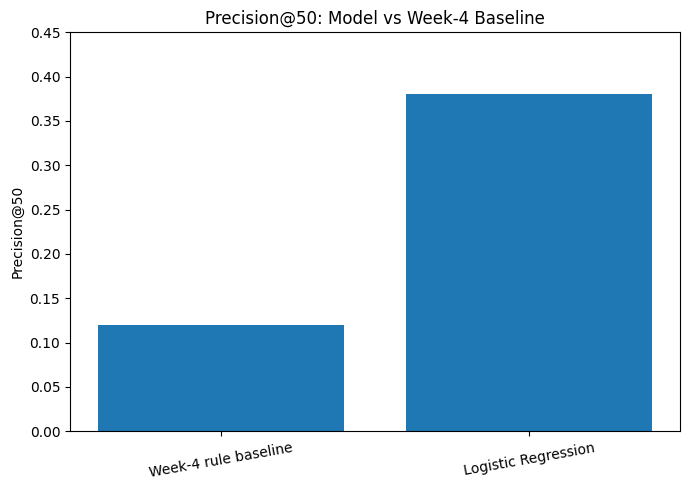

In [33]:
# ============================================================
# Paper chart — Model vs baseline
# ============================================================

plt.figure(figsize=(7, 5))

plt.bar(
    results_summary["method"],
    results_summary["Precision@50"]
)

plt.ylabel("Precision@50")
plt.title("Precision@50: Model vs Week-4 Baseline")
plt.ylim(0, 0.45)
plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

# ML-12 — 5-Minute Demo Outline

## 0:00–1:00 — The question

Can a simple machine-learning ranking model help prioritize content items for review based on signals available before the next month's performance?

The practical decision is: which content items should be reviewed first when the available content inventory is too large for manual review?

## 1:00–2:00 — The method

I used March 2026 decision-time features from Google Search Console and GA4, with April 2026 organic clicks used to define the future outcome.

The model is Logistic Regression using five features: clicks, impressions, average position, GA4 sessions, and scroll events.

Evaluation uses a grouped train/test split by client to prevent the same client from appearing in both sets.

## 2:00–3:00 — The result

Show the Precision@50 comparison chart.

The Logistic Regression model achieved **0.3800 Precision@50**, compared with **0.1200** for the Week-4 rule-based baseline on the same held-out test split.

The test positive rate was **0.1641**.

## 3:00–4:00 — What the result means

The model concentrated more positive outcomes in its top-50 ranked items than the baseline on this evaluation split.

This is an observed ranking improvement and should be treated as directional decision-support evidence, not as proof that the model or a content refresh causes traffic growth.

## 4:00–5:00 — The recommendation

Use the model as a prioritization layer:

**Rank → Review → Refresh if justified → Measure → Learn**

The model should narrow the review queue, while human reviewers make the final decision based on search intent, content quality, relevance, and other business considerations.

# ML-12 — Shareable Cuts

## Social Post

I built a machine-learning ranking workflow to help prioritize content items for review.

Using public-safe FlyRank internship data, I used March 2026 search and engagement signals to rank content items by their likelihood of experiencing increased organic clicks in April.

On a grouped held-out test split, Logistic Regression achieved **0.3800 Precision@50**, compared with **0.1200** for the Week-4 rule-based baseline.

The result is directional decision-support evidence, not a causal claim: the model helps identify what to review first, while human judgment remains part of the workflow.

#MachineLearning #SEO #ContentOptimization #DataScience #AI

---

## Employer-Facing Summary

I built a Logistic Regression ranking model using FlyRank internship data to prioritize content items for review based on five March 2026 search and engagement features. On a grouped held-out test split, the model achieved **0.3800 Precision@50**, compared with **0.1200** for the existing Week-4 rule-based baseline. The project demonstrates an end-to-end, public-safe ML workflow from data preparation and leakage-aware validation to model evaluation and actionable content prioritization.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
